In [38]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/Walmart_Sales.csv')

In [39]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date')
df = df.dropna()

In [40]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

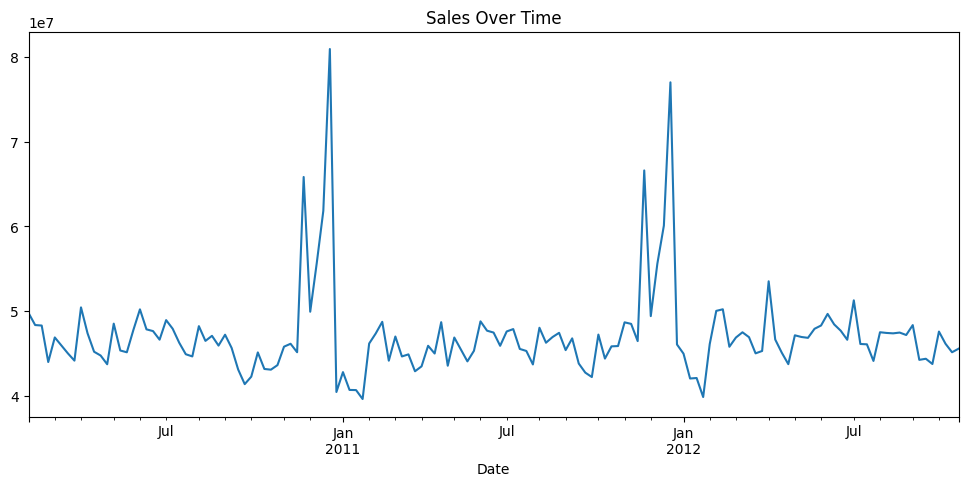

In [41]:
df.groupby('Date')['Weekly_Sales'].sum().plot(figsize=(12,5), title="Sales Over Time")
plt.show()

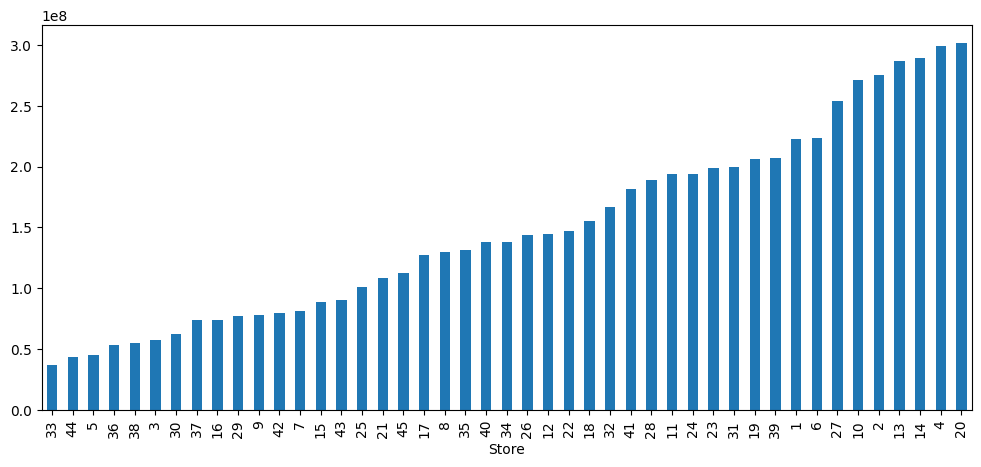

In [42]:
df.groupby('Store')['Weekly_Sales'].sum().sort_values().plot(kind='bar', figsize=(12,5))
plt.show()

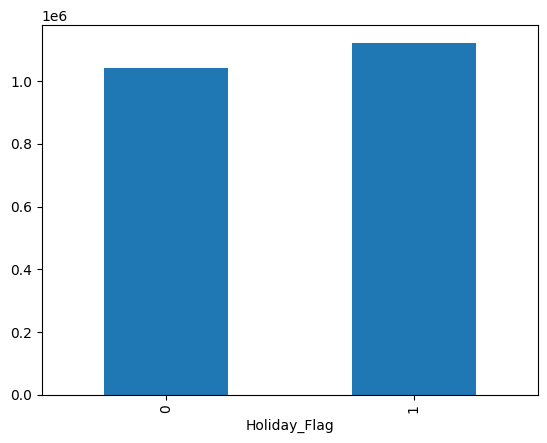

In [43]:
df.groupby('Holiday_Flag')['Weekly_Sales'].mean().plot(kind='bar')
plt.show()

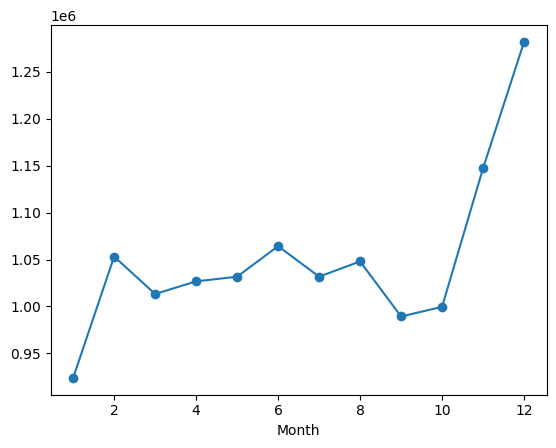

In [44]:
df.groupby('Month')['Weekly_Sales'].mean().plot(kind='line', marker='o')
plt.show()

In [45]:
from statsmodels.tsa.arima.model import ARIMA

ts = df.groupby('Date')['Weekly_Sales'].sum()

model = ARIMA(ts, order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=5)
print(forecast)

2012-11-02    4.631238e+07
2012-11-09    4.666243e+07
2012-11-16    4.682193e+07
2012-11-23    4.689460e+07
2012-11-30    4.692771e+07
Freq: W-FRI, Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


In [46]:
print("""
Sales show clear trends and seasonal patterns.
Holiday periods increase sales performance.
Some stores outperform others significantly.
Monthly trends indicate seasonal behavior.
ARIMA forecasting provides future sales predictions.
This project demonstrates real business analytics.
""")


Sales show clear trends and seasonal patterns.
Holiday periods increase sales performance.
Some stores outperform others significantly.
Monthly trends indicate seasonal behavior.
ARIMA forecasting provides future sales predictions.
This project demonstrates real business analytics.

